#### Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

#### Carga de csv limpio

In [2]:
df_est = pd.read_csv('../../data/clean_viajeros_07_04_2026.csv')

In [3]:
month_map = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}

df_est["num_mes"] = df_est["mes"].map(month_map)

#### Analisis por año

In [4]:
# Agregación mensual global
df_season = (
    df_est
    .groupby(["año", "num_mes"])["qty_viajeros"]
    .sum()
    .reset_index()
)

In [5]:
df_season["avg_año"] = (
    df_season.groupby("año")["qty_viajeros"]
    .transform("mean")
)

df_season["seasonality_index"] = (
    df_season["qty_viajeros"] / df_season["avg_año"]
)

In [6]:
df_season["num_mes"] = df_season["num_mes"].astype(int)
df_season = df_season.sort_values(["año", "num_mes"])

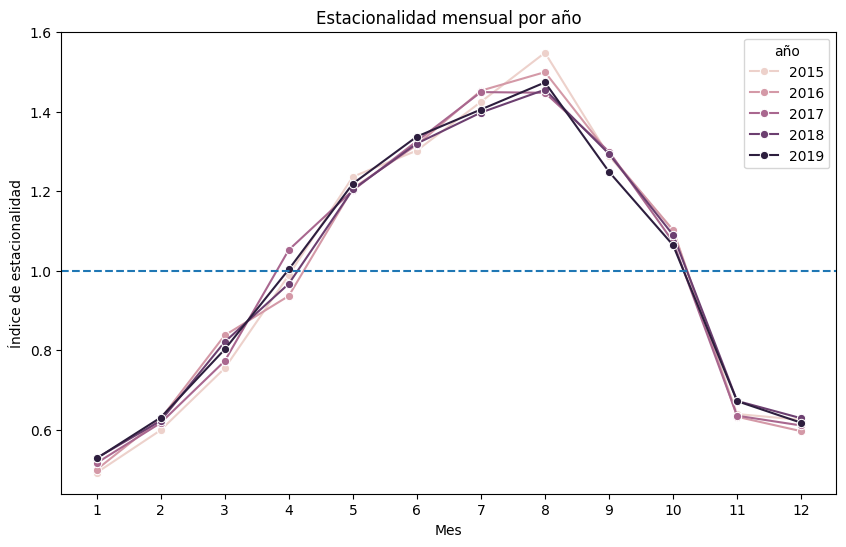

In [7]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df_season,
    x="num_mes",
    y="seasonality_index",
    hue="año",
    marker="o"
)

plt.axhline(1, linestyle="--") 

plt.title("Estacionalidad mensual por año")
plt.xlabel("Mes")
plt.ylabel("Índice de estacionalidad")
plt.xticks(range(1,13))

plt.show()

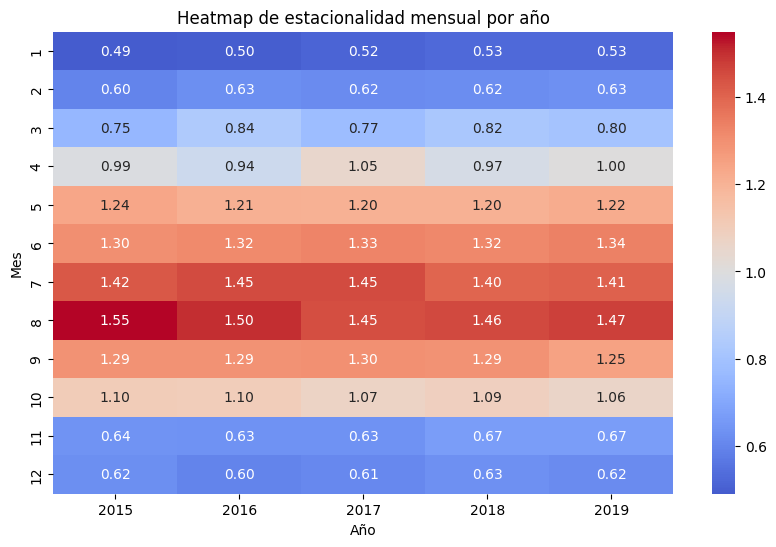

In [8]:
pivot = df_season.pivot(
    index="num_mes",
    columns="año",
    values="seasonality_index"
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=1
)

plt.title("Heatmap de estacionalidad mensual por año")
plt.xlabel("Año")
plt.ylabel("Mes")

plt.show()

#### Análisis por CCAA

In [9]:
df_est_ccaa = (
    df_est
    .groupby(["año", "num_mes", "ccaa"])["qty_viajeros"]
    .sum()
    .reset_index()
)

df_est_ccaa["avg_año_ccaa"] = (
    df_est_ccaa
    .groupby(["año", "ccaa"])["qty_viajeros"]
    .transform("mean")
)

df_est_ccaa["indice_estacionalidad"] = (
    df_est_ccaa["qty_viajeros"] / df_est_ccaa["avg_año_ccaa"]
)

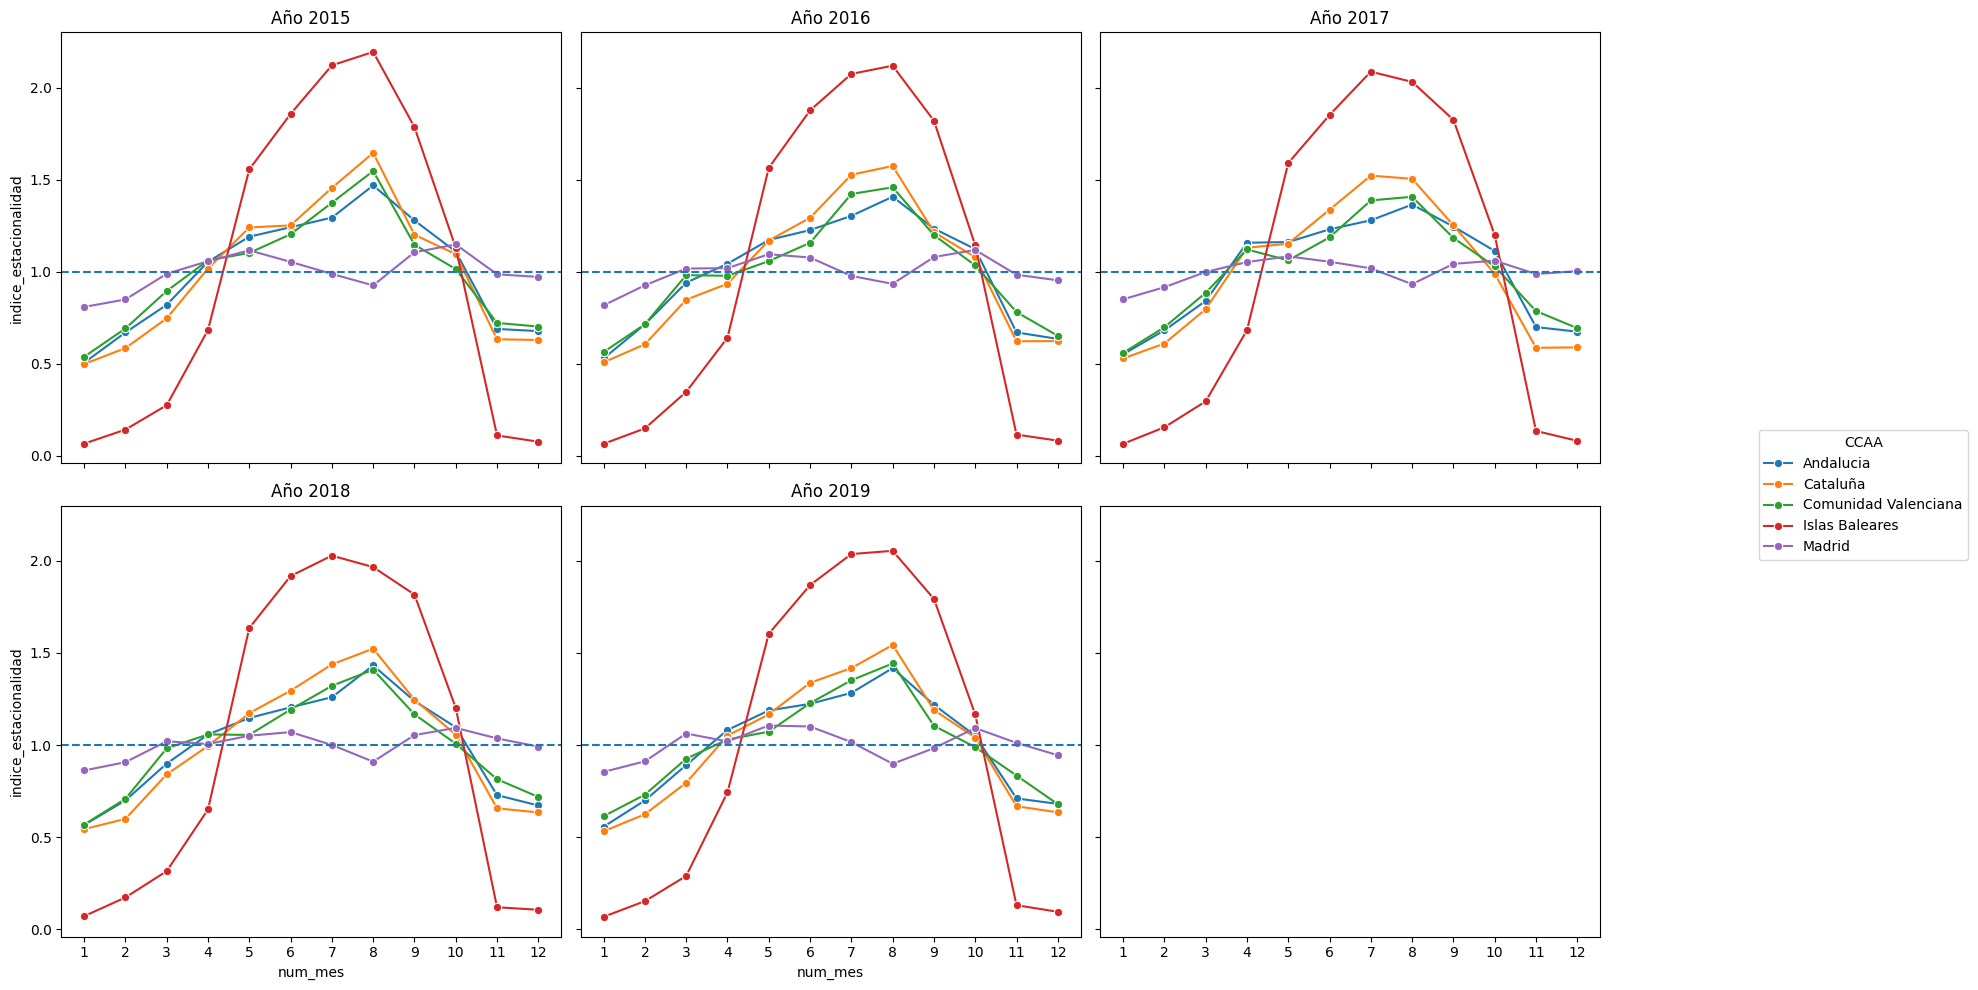

In [10]:
years = sorted(df_est["año"].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18,10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for i, año in enumerate(years):
    
    ax = axes[i]
    
    data_year = df_est_ccaa[df_est_ccaa["año"] == año]
    
    sns.lineplot(
        data=data_year,
        x="num_mes",
        y="indice_estacionalidad", 
        hue="ccaa",
        marker="o",
        ax=ax
    )
    
    ax.axhline(1, linestyle="--") 
    ax.set_title(f"Año {año}")
    ax.set_xticks(range(1,13))
    
    # eliminar leyendas individuales
    if ax.get_legend() is not None:
        ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="CCAA",
    loc="center right",
    bbox_to_anchor=(1.1, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

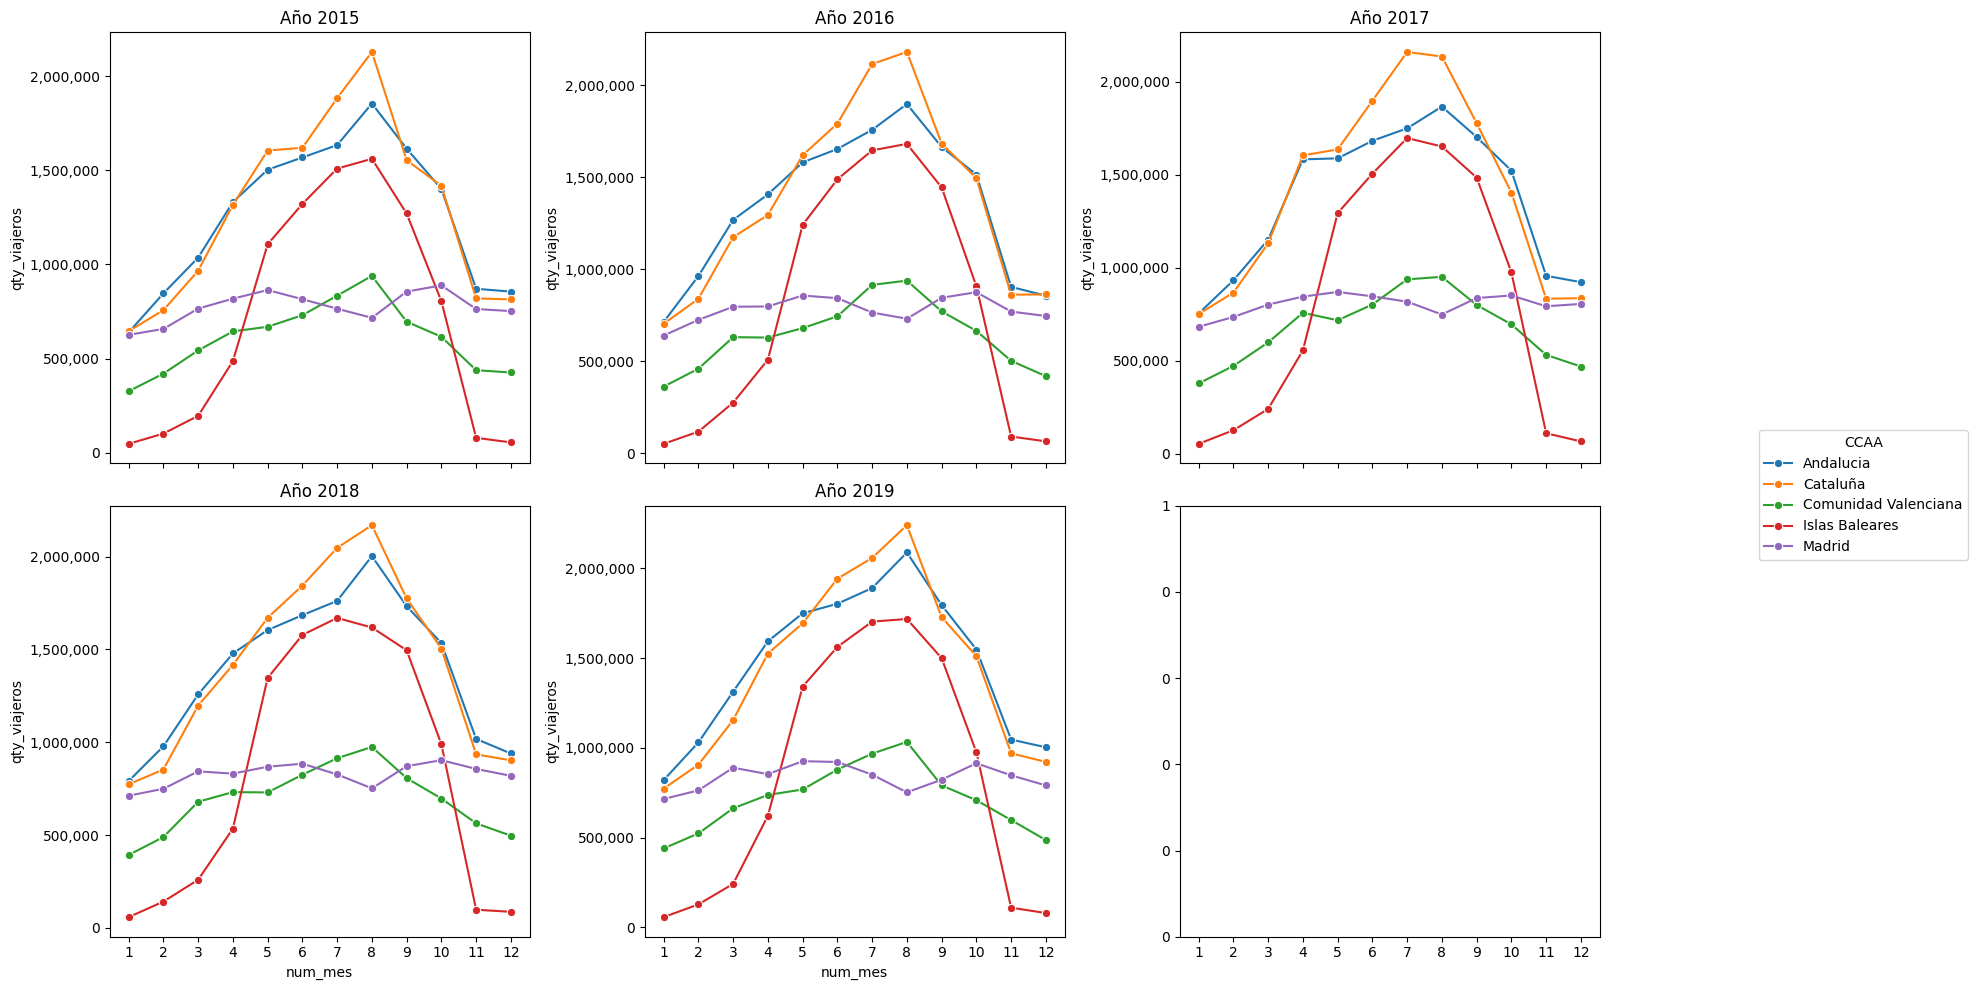

In [11]:
years = sorted(df_est_ccaa["año"].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18,10),
    sharex=True,
    sharey=False  # 🔥 importante
)

axes = axes.flatten()

for i, año in enumerate(years):
    
    ax = axes[i]
    
    data_year = df_est_ccaa[df_est_ccaa["año"] == año]
    
    sns.lineplot(
        data=data_year,
        x="num_mes",
        y="qty_viajeros",
        hue="ccaa",
        marker="o",
        ax=ax
    )
    
    ax.set_title(f"Año {año}")
    ax.set_xticks(range(1,13))

    # eliminar leyenda individual
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# leyenda global
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="CCAA",
    loc="center right",
    bbox_to_anchor=(1.1, 0.5)
)

for ax in axes:
    ax.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()
